In [1]:
# Colab Setup (Run this first)

In [2]:
!pip install litebird_sim rich


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


To run this notebook, you have several options:

-   If you are running this under Binder, you should already be set!
-   If you are running this under Google Colab, be sure to run the cell with `!pip install…` that is right above the title.
-   If you are running this locally, you should first create and activate a new virtual environment with the commands

    ```
    python -m venv ./my_venv
    source ./my_venv/bin/activate
    ```

    (you can use Conda environments, if you prefer) and install Jupyter and litebird_sim in it:

    ```
    pip install jupyter litebird_sim
    ```

    If you have a local copy of the `litebird_sim` repository cloned from <https://github.com/litebird/litebird_sim> (e.g., because you're part of the Simulation Team!), you can use a _development install_ instead:

    ```
    cd /my/local/copy/litebird_sim
    pip install -e .
    ```


## Import Modules

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from litebird_sim.input_sky import SkyGenerator, SkyGenerationParams
from litebird_sim.units import Units
import litebird_sim as lbs

## Define Parameters

In [4]:
start_time = 0
time_span_s = 30 * 24 * 3600
nside = 64
imo_location = "schema.json"
imo = lbs.Imo(flatfile_location=imo_location)
imo_version = "IMo_vPostKDP2_Option2"

## Create Simulation

In [5]:
sim = lbs.Simulation(
    start_time=start_time, duration_s=time_span_s, random_seed=0, imo=imo
)

comm = sim.mpi_comm

## Define Frequency Channel

In [6]:
channel = "M1_L"

channelinfo = lbs.FreqChannelInfo.from_imo(
    url=f"/releases/{imo_version}/LMHFT/{channel}/channel_info",
    imo=imo,
)

## Define Scanning Strategy

In [7]:
sim.set_scanning_strategy(
    imo_url=f"/releases/{imo_version}/Observation/Scanning_Strategy"
)

## Define Instrument

In [8]:
instrument_info = lbs.InstrumentInfo.from_imo(
    imo,
    f"/releases/{imo_version}/LMHFT/instrument_info",
)

sim.set_instrument(instrument_info)

hwp_radpsec = instrument_info.hwp_rpm * 2 * np.pi / 60

## Set HWP

In [9]:
sim.set_hwp(
    lbs.NonIdealHWP(
        hwp_radpsec,
        harmonic_expansion=True,
        calculus=lbs.Calc.JONES,
        jones_per_freq_csv_path="jones_params.txt",
    )
)

## Define Detectors

In [10]:
det = lbs.DetectorInfo.from_imo(
    url=f"/releases/{imo_version}/LMHFT/{channel}/{channelinfo.detector_names[0]}/detector_info",
    imo=imo,
)

[2026-02-25 19:03:42,110 WARNING MPI#0000] Detector '005_000_XX_094_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)


## Create Observations and Prepare Pointings

In [11]:
(obs,) = sim.create_observations(
    detectors=[det],
)

sim.prepare_pointings(append_to_report=False)

## Generate Input Sky Maps

In [12]:
params = SkyGenerationParams(
    nside=64,
    units=Units.K_CMB,
    output_type="map",
    make_cmb=True,
    seed_cmb=12345,
    make_fg=True,
    make_dipole=True,
    fg_models=["d1", "s1"],
    apply_beam=True,
)

data = np.loadtxt(
    "jones_params.txt",
    delimiter=",",
    dtype=object,
    unpack=True,
    skiprows=1,
    comments="#",
)

frequencies = data[0, :].astype(np.float64)
indices = np.where(
    (frequencies >= det.bandcenter_ghz - det.bandwidth_ghz/2)
    & (frequencies <= det.bandcenter_ghz + det.bandwidth_ghz/2)
)[0]

frequencies_ghz = frequencies[indices]
fwhm_arcmin = 37.805193
fwhm_rad = np.radians(fwhm_arcmin / 60.0)

sky_gen = SkyGenerator(
    parameters=params,
    frequencies_ghz=frequencies_ghz,
    fwhm_rad=fwhm_rad,
)
sky_map = sky_gen.execute()

[2026-02-25 19:03:42,253 INFO MPI#0000] Generating CMB (frequency mode)...
[2026-02-25 19:03:42,284 INFO MPI#0000] Generating Foregrounds (frequency mode)...
[2026-02-25 19:03:42,284 INFO MPI#0000] Retrieve data for pysm_2/dust_t_new.fits (if not cached already)
[2026-02-25 19:03:42,285 INFO MPI#0000] NSIDE = 512
[2026-02-25 19:03:42,286 INFO MPI#0000] ORDERING = RING in fits file
[2026-02-25 19:03:42,286 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-02-25 19:03:42,322 INFO MPI#0000] Retrieve data for pysm_2/dust_q_new.fits (if not cached already)
[2026-02-25 19:03:42,323 INFO MPI#0000] NSIDE = 512
[2026-02-25 19:03:42,323 INFO MPI#0000] ORDERING = RING in fits file
[2026-02-25 19:03:42,323 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-02-25 19:03:42,355 INFO MPI#0000] Retrieve data for pysm_2/dust_u_new.fits (if not cached already)
[2026-02-25 19:03:42,356 INFO MPI#0000] NSIDE = 512
[2026-02-25 19:03:42,356 INFO MPI#0000] ORDERING = RING in fits file
[2026-02-25 19:03:42,356 INFO MPI#0000] INDX

## Generate HwpSys object and Set its parameters

## Fill TOD and perform Mapmaking on-the-fly

In [13]:
lbs.scan_map_in_observations(
    observations=[obs],
    maps=sky_map, # type: ignore[invalid-argument-type]
    integrate_in_band=True,
)

In [14]:
output_map = sim.make_brahmap_gls_map(
    nside=64,
).GLS_maps


-------------------------- ProcessTimeSamples Summary --------------------------
Processed 194400000 time samples for npix=49152
Found 20799 pathological pixels on the map
Map-maker will take into account only 28353 pixels
--------------------------------------------------------------------------------


## Show Output Maps

[ 83.64705882  88.29411765  92.94117647  97.58823529 102.2352941
 106.8823529 ]


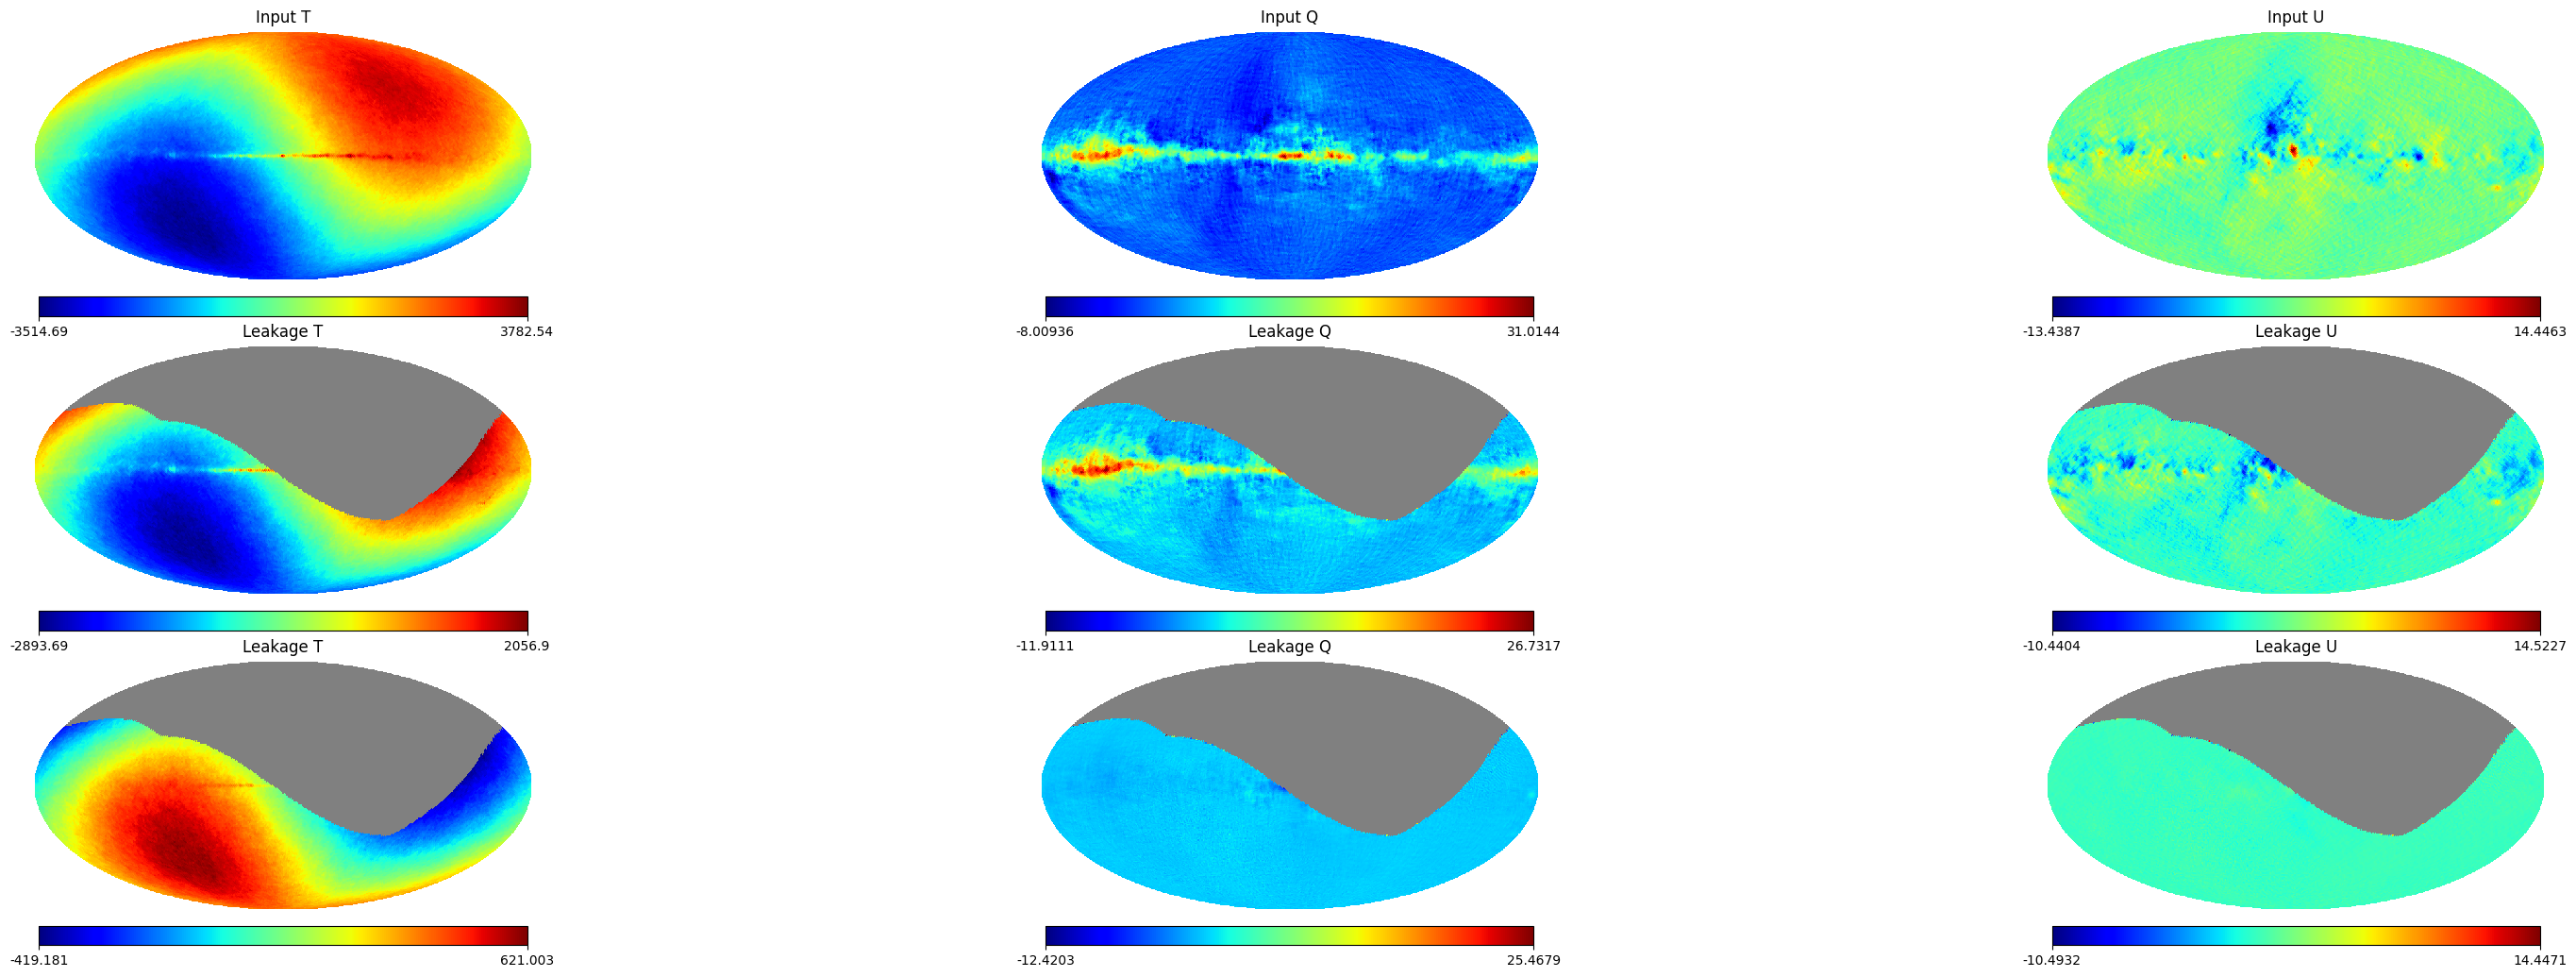

In [15]:
plt.figure(figsize=(32, 10))
stokes_parameters = ["T", "Q", "U"]
print(frequencies_ghz)
input_map=sky_map.values[0,:] * 1e6
output_normalized = 1e6 * (output_map / det.bandwidth_ghz)
for i in range(3):
    hp.mollview(
        input_map[i], # type: ignore[not-subscriptable]
        cmap="jet",
        sub=(3, 3, i + 1),
        title="Input " + stokes_parameters[i],
    )

    hp.mollview(
        output_normalized[i],
        cmap="jet",
        sub=(3, 3, i + 4),
        title="Leakage " + stokes_parameters[i],
    )

    hp.mollview(
        (output_normalized[i]-sky_map.values[0, i]*1e6),
        cmap="jet",
        sub=(3, 3, i + 7),
        title="Leakage " + stokes_parameters[i],
    )